In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
from glint.lensing import map_source_to_image, make_grid_arcsec, deflection_SIE_plus_ES
from glint.context import ImageContext
from glint.forward import forward_model_2D_image
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style
from glint.sli import build_matrix_lensing

In [2]:
set_my_plot_style()

## Select data for fitting

In [3]:
option = ["cont", "CII_mom0"]

fit_data = option[1]  # choose which data to fit

## Data

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


hst peak: 8.0, 17.0 pix, corresponding to 0.160, 0.340 arcsec from the center
hst centroid: 4.7, 3.5 pix, corresponding to 0.093, 0.070 arcsec from the center
hst gaussian fit: 10.8, 14.5 pix, corresponding to 0.217, 0.290 arcsec from the center
Number of pixels in the mask: 40401
Number of pixels in image plane: 201 x 201
Pixel scale in image plane: 0.02 arcsec/pixel


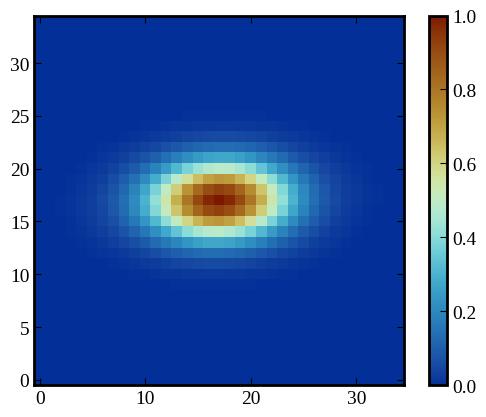

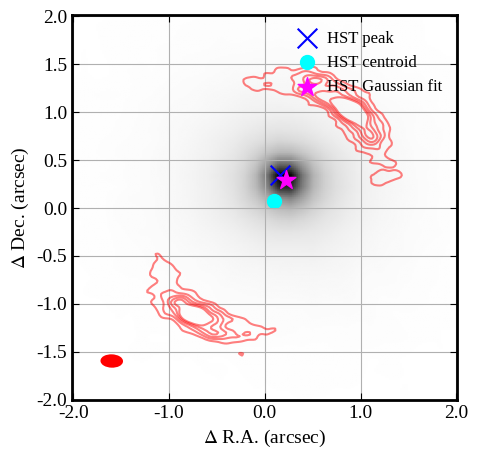

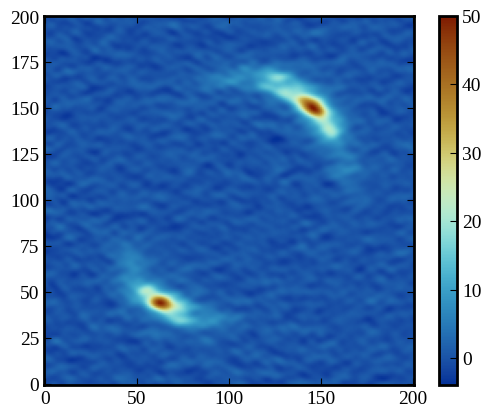

In [4]:
# image data
data_dir = Path("./data").resolve()
data_dir.exists()

obsfits   = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.image.pbcor.cutout.-250+300km.m0.fits")
noisefits = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.noise.pbcor.cutout.-250+300km.m0.fits")

obsdata, obsheader = fits.getdata(obsfits, header=True)
noisedata = fits.getdata(noisefits)
noisedata_inv = 1/noisedata



#### Continuum data for overlay ####
contfits   = str(data_dir / "B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits")
contnoisefits = str(data_dir / "B6_concat_cont_rob-0.5_clean.noise.pbcor.cutout.fits")

contdata, contheader = fits.getdata(contfits, header=True)
contnoisedata = fits.getdata(contnoisefits)
####

#### select data to fit ####
if fit_data == "cont":
    obsheader = contheader
else:
    obsheader = obsheader
beam = cleanbeam_from_header(35, obsheader)
BMAJ, BMIN, BPA, CDELT = obsheader['BMAJ'], obsheader['BMIN'], obsheader['BPA'], obsheader['CDELT2']
plt.imshow(beam, origin="lower", cmap=cm.roma_r)
plt.colorbar()
####

# あとは同じ
hst_fits = str(data_dir / "hst_skycell-p1356x14y05_wfc3_ir_f125w_coarse-all_drz.fits")
hst_data, hst_header = fits.getdata(hst_fits, header=True)
hst_wcs = WCS(hst_header)

# reproject to ALMA
hst_on_alma, footprint = reproject_interp((hst_data, hst_wcs), WCS(contheader, naxis=2), shape_out=contdata.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(hst_on_alma, origin='lower', cmap='gray_r')
ax.contour(contdata/contnoisedata, levels=[4,8,12,16,20], colors='red', alpha=0.5)

# 画像の中心
ny, nx = contdata.shape
x0 = (nx - 1) / 2
y0 = (ny - 1) / 2
pixscale_as = abs(obsheader['CDELT2'] * 3600) # arcsec/pix
def format_func_x(x_pix, _):
    return f"{(x_pix - x0) * pixscale_as:.1f}"
def format_func_y(y_pix, _):
    return f"{(y_pix - y0) * pixscale_as:.1f}"
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(format_func_x))
ax.yaxis.set_major_formatter(FuncFormatter(format_func_y))

# psfサイズをimage planeの左下に楕円として表示
xy_beam = (0.10*nx, 0.10*ny)
ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90, edgecolor='red', facecolor='red', lw=1.5)
ax.add_patch(ellipse)
ax.grid()

# HST peak
hst_peak = np.unravel_index(np.nanargmax(hst_on_alma), hst_on_alma.shape)
ax.scatter(hst_peak[1], hst_peak[0], marker='x', color='blue', s=200, label='HST peak')

# HST centroid
from photutils.centroids import centroid_com
y_com, x_com = centroid_com(hst_on_alma)
ax.scatter(x_com, y_com, marker='o', color='cyan', s=100, label='HST centroid')

# HST gaussian fit
def gauss2d(p, x, y):
    A, x0, y0, sx, sy, rho, c = p
    # 相関rho入り楕円ガウス：必要なければ rho=0 に固定
    X = (x - x0); Y = (y - y0)
    z = (X/sx)**2 + (Y/sy)**2 - 2*rho*X*Y/(sx*sy)
    return A*np.exp(-0.5/(1-rho**2) * z) + c
ny, nx = hst_on_alma.shape
yy, xx = np.indices((ny, nx))
p0 = [hst_on_alma.max(), x_com, y_com, 3.0, 3.0, 0.0, 0.0]
use = np.isfinite(hst_on_alma)
def resid(p): return (gauss2d(p, xx[use], yy[use]) - hst_on_alma[use])
res = least_squares(resid, p0, bounds=([0,0,0,0.5,0.5,-0.5,-np.inf],
                                       [np.inf,nx,ny,50,50,0.5,np.inf]))
A,x0_g,y0_g,sx,sy,rho,c = res.x
ax.scatter(x0_g, y0_g, marker='*', color='magenta', s=200, label='HST Gaussian fit')

ax.set_xlabel(r"$\Delta$ R.A. (arcsec)", fontsize=14)
ax.set_ylabel(r"$\Delta$ Dec. (arcsec)", fontsize=14)
ax.legend(fontsize=12)
print(f"hst peak: {hst_peak[1]-x0:.1f}, {hst_peak[0]-y0:.1f} pix, corresponding to {((hst_peak[1]-x0)*pixscale_as):.3f}, {((hst_peak[0]-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst centroid: {x_com-x0:.1f}, {y_com-y0:.1f} pix, corresponding to {((x_com-x0)*pixscale_as):.3f}, {((y_com-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst gaussian fit: {x0_g-x0:.1f}, {y0_g-y0:.1f} pix, corresponding to {((x0_g-x0)*pixscale_as):.3f}, {((y0_g-y0)*pixscale_as):.3f} arcsec from the center")

x0_l = (x0_g-x0)*pixscale_as
y0_l = (y0_g-y0)*pixscale_as


# mask definition
maskdata = np.zeros(contdata.shape).astype(bool)

# RMS基準にマスクを定義する場合
# thresh = 2
# maskdata[obsdata*noisedata_inv > thresh] = True

# 固定マスクを使う場合
# 円環マスク
r_inner = 0.4 # arcsec
r_outer = 2.0 # arcsec
y, x = np.indices(contdata.shape)
x_center = contdata.shape[1] / 2
y_center = contdata.shape[0] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * np.abs(CDELT) * 3600
# maskdata[(r >= r_inner) & (r <= r_outer)] = True
maskdata = np.ones(contdata.shape).astype(bool)


Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")

# mask
# obsdata[maskdata==0] = np.nan
# noisedata_inv[maskdata==0] = np.nan

fig, ax = plt.subplots()
im = ax.imshow(contdata/contnoisedata, origin="lower", cmap=cm.roma_r)
ax.contour(maskdata)
fig.colorbar(im, ax=ax)



# source plane grid
ny_src, nx_src = 400, 400
pixsize_src = 0.005 # arcsec
x0_src, y0_src = 0.0, 0.0
xx_src, yy_src = make_grid_arcsec(nx=nx_src, ny=ny_src, pixscale_arcsec=pixsize_src, x0_arcsec=x0_src, y0_arcsec=y0_src)

# image plane grid
ny_img, nx_img = obsdata.shape
pixsize_img = (np.abs(obsheader['CDELT2'])*3600).round(5)
print(f"Number of pixels in image plane: {nx_img} x {ny_img}")
print(f"Pixel scale in image plane: {pixsize_img} arcsec/pixel")
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

## Common setting

In [5]:
ctx = ImageContext(
    xx_img = xx_img,
    yy_img = yy_img,
    xx_src = xx_src,
    yy_src = yy_src,
    pixsize_img = pixsize_img,
    pixsize_src = pixsize_src,
    x0_src = x0_src,
    y0_src = y0_src,
    x0_l = x0_l,
    y0_l = y0_l,
    beam = beam
)

In [6]:
if fit_data == "cont":
    from params_cont import param_names, param_table
    obsdata = contdata
    noisedata = contnoisedata
    noisedata_inv = 1/noisedata
elif fit_data == "CII_mom0":
    from params_CII_mom0 import param_names, param_table
    obsdata = obsdata
    noisedata = noisedata
    noisedata_inv = 1/noisedata

In [7]:
# 適当なレンズを仮定
from params_CII_mom0 import param_names, param_table

p = param_table[:, 0].copy()

x_s, y_s, F_0, ellip, pa_deg, r_eff, n, \
        b, q_l, pa_l, log_gamma, pa_gamma = p

alpha_x_as, alpha_y_as = deflection_SIE_plus_ES(
        xx=ctx.xx_img, yy=ctx.yy_img,
        # x0=x_l, y0=y_l, b=b, q=q_l, pa=pa_l,
        x0=ctx.x0_l, y0=ctx.y0_l, b=b, q=q_l, pa=pa_l, # lens centerはHST Gaussian fitで固定している
        log_gamma=log_gamma, pa_gamma=pa_gamma, kappa=0
    )

beta_x_arcsec, beta_y_arcsec = ctx.xx_img - alpha_x_as, ctx.yy_img - alpha_y_as

In [8]:


# 1) 適当な source を作る
S = np.zeros(ctx.xx_src.shape, dtype=np.float32)
S[180:220, 150:190] = 1  # 1点だけ光らせる
s = S.ravel()

# 2) 行列でimageを作る
L = build_matrix_lensing(beta_x_arcsec=beta_x_arcsec, 
                         beta_y_arcsec=beta_y_arcsec, 
                         mask=maskdata, ctx=ctx)
I1 = (L @ s)  # (Nimg_used,)

# 3) map_source_to_image でimageを作る（同じ mask の点だけ比較）
Imap = map_source_to_image(beta_x_arcsec, beta_y_arcsec, S,
                           src_pixscale_arcsec=ctx.pixsize_src,
                           order=1, x0_src_arcsec=ctx.x0_src, y0_src_arcsec=ctx.y0_src)
I2 = Imap.ravel()[maskdata.ravel()]

print("max abs diff:", np.max(np.abs(I1 - I2)))

(38364,)
max abs diff: 2.9152943170629442e-08


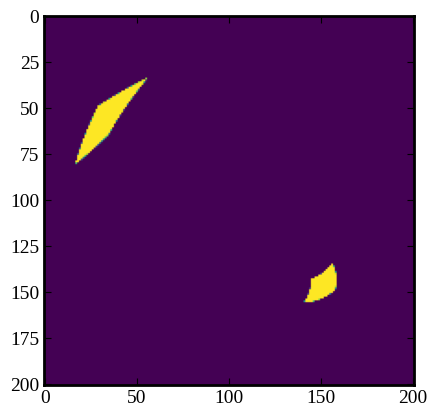

In [9]:
plt.imshow(Imap)

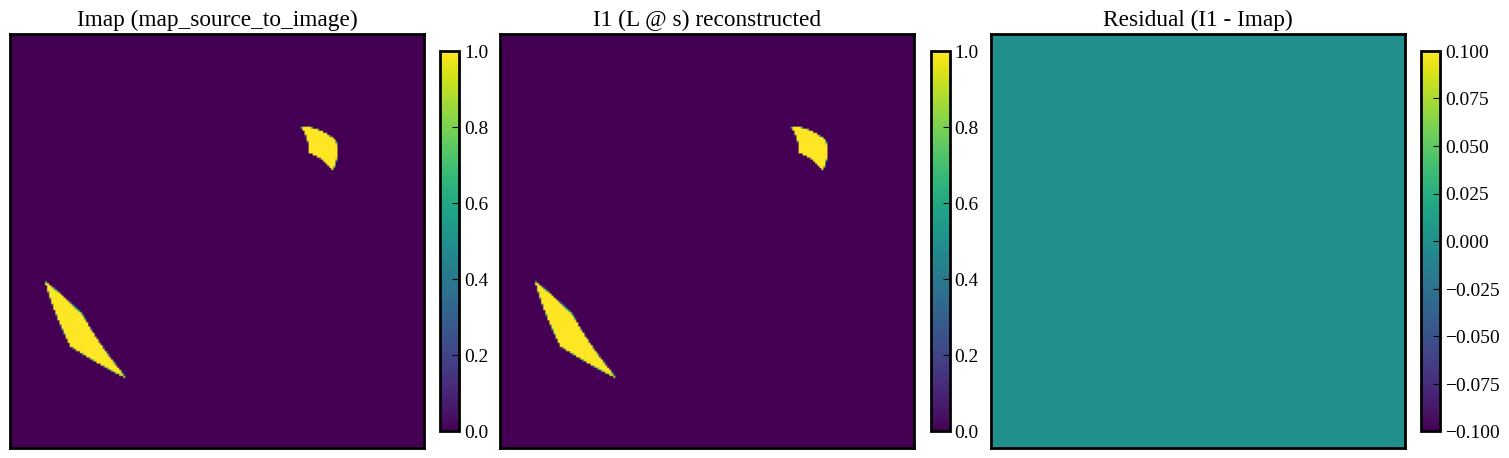

max |residual| on mask = 0.0


In [10]:
import numpy as np
import matplotlib.pyplot as plt

mask_flat = maskdata.ravel()

# 1) (L @ s) は mask で抜いた1次元なので、全画素に戻す
I1_full = np.zeros(mask_flat.size, dtype=np.float32)   # (ny*nx,)
I1_full[mask_flat] = I1                                # mask部分だけ埋める
I1_img = I1_full.reshape(Imap.shape)                   # (ny, nx)

# 2) 残差
res_img = I1_img - Imap

# 3) 画像比較のため、表示レンジを揃える（任意）
vmin = np.nanmin(Imap[maskdata])
vmax = np.nanmax(Imap[maskdata])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axes[0].imshow(Imap, origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Imap (map_source_to_image)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(I1_img, origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("I1 (L @ s) reconstructed")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# 残差は対称レンジ（任意）
rmax = np.nanmax(np.abs(res_img[maskdata]))
im2 = axes[2].imshow(res_img, origin="lower", vmin=-rmax, vmax=rmax)
axes[2].set_title("Residual (I1 - Imap)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

print("max |residual| on mask =", np.nanmax(np.abs(res_img[maskdata])))